# Zero-Variance Handling in Reflectometry Fitting

This notebook demonstrates how `easyreflectometry` handles data points with **zero variance**
during fitting. We compare three objective strategies:

| Objective | Behaviour |
|---|---|
| `legacy_mask` | Drops zero-variance points entirely (old default) |
| `hybrid` | Keeps all points; applies Mighell substitution only to zero-variance entries (**new default**) |
| `mighell` | Applies the Mighell (1999) transform to every point |

The experimental data comes from `tests/_static/ref_zero_var.txt`, which contains 192 data points,
6 of which have zero error (= zero variance).

## 1. Import Required Libraries

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipp as sc

from easyreflectometry.calculators import CalculatorFactory
from easyreflectometry.data.measurement import load
from easyreflectometry.fitting import MultiFitter
from easyreflectometry.model import Model
from easyreflectometry.model import PercentageFwhm
from easyreflectometry.sample import Layer
from easyreflectometry.sample import Material
from easyreflectometry.sample import Multilayer
from easyreflectometry.sample import Sample

%matplotlib inline

## 2. Load Experimental Data

The file `ref_zero_var.txt` is a comma-separated file with columns: `q (Å⁻¹)`, `R`, `error`.
Several points near the high-Q end have `error = 0.0`, meaning zero variance.

In [2]:
DATA_PATH = os.path.join('..', 'tests', '_static', 'ref_zero_var.txt')

# Load raw data for inspection
raw = np.loadtxt(DATA_PATH, delimiter=',', comments='#')
q_raw, r_raw, err_raw = raw[:, 0], raw[:, 1], raw[:, 2]

# Load through easyreflectometry (produces a scipp DataGroup)
data = load(DATA_PATH)

print(f'Total data points : {len(q_raw)}')
print(f'Q range           : [{q_raw.min():.4e}, {q_raw.max():.4e}] Å⁻¹')
print(f'R range           : [{r_raw.min():.4e}, {r_raw.max():.4e}]')

Total data points : 192
Q range           : [7.6135e-03, 3.3436e-01] Å⁻¹
R range           : [3.1715e-07, 1.0429e+00]


## 3. Inspect Data and Identify Zero-Variance Points

In [3]:
zero_mask = err_raw == 0.0
zero_indices = np.where(zero_mask)[0]
print(f'Number of zero-variance points: {zero_mask.sum()}')
print(f'Indices: {zero_indices}')
print(f'Q-values with zero variance:')
for idx in zero_indices:
    print(f'  [{idx:3d}]  Q = {q_raw[idx]:.4e} Å⁻¹,  R = {r_raw[idx]:.4e}')

Number of zero-variance points: 6
Indices: [170 179 183 189 190 191]
Q-values with zero variance:
  [170]  Q = 2.2061e-01 Å⁻¹,  R = 7.8023e-07
  [179]  Q = 2.6364e-01 Å⁻¹,  R = 6.5027e-07
  [183]  Q = 2.8538e-01 Å⁻¹,  R = 4.6847e-07
  [189]  Q = 3.2138e-01 Å⁻¹,  R = 3.1715e-07
  [190]  Q = 3.2781e-01 Å⁻¹,  R = 3.4336e-07
  [191]  Q = 3.3436e-01 Å⁻¹,  R = 3.2231e-07


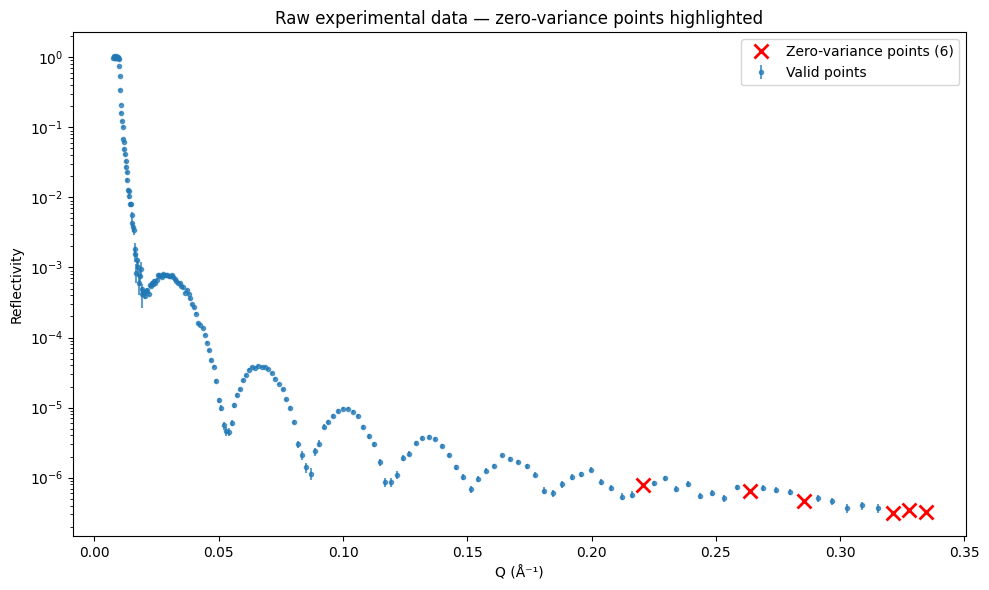

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all data
valid = ~zero_mask
ax.errorbar(q_raw[valid], r_raw[valid], yerr=err_raw[valid],
            fmt='o', ms=3, color='C0', alpha=0.7, label='Valid points')
ax.plot(q_raw[zero_mask], r_raw[zero_mask],
        'rx', ms=10, mew=2, label=f'Zero-variance points ({zero_mask.sum()})')

ax.set_yscale('log')
ax.set_xlabel('Q (Å⁻¹)')
ax.set_ylabel('Reflectivity')
ax.set_title('Raw experimental data — zero-variance points highlighted')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Define Materials

A simple film-on-substrate structure: **Si** substrate / **SiO₂** native oxide / **Film** / **D₂O** superphase.

In [5]:
si = Material(2.07, 0, 'Si')
sio2 = Material(3.47, 0, 'SiO2')
film = Material(2.0, 0, 'Film')
d2o = Material(6.36, 0, 'D2O')

## 5. Define Layers and Sample Structure

In [6]:
si_layer = Layer(si, 0, 0, 'Si layer')
sio2_layer = Layer(sio2, 30, 3, 'SiO2 layer')
film_layer = Layer(film, 250, 3, 'Film layer')
superphase = Layer(d2o, 0, 3, 'D2O superphase')

sample = Sample(
    Multilayer(si_layer),
    Multilayer(sio2_layer),
    Multilayer(film_layer),
    Multilayer(superphase),
    name='Film Structure',
)
print(sample)

Film Structure:
- EasyMultilayer:
    Si layer:
    - Si layer:
        material:
          Si:
            sld: 2.070e-6 1/Å^2
            isld: 0.000e-6 1/Å^2
        thickness: 0.000 Å
        roughness: 0.000 Å
- EasyMultilayer:
    SiO2 layer:
    - SiO2 layer:
        material:
          SiO2:
            sld: 3.470e-6 1/Å^2
            isld: 0.000e-6 1/Å^2
        thickness: 30.000 Å
        roughness: 3.000 Å
- EasyMultilayer:
    Film layer:
    - Film layer:
        material:
          Film:
            sld: 2.000e-6 1/Å^2
            isld: 0.000e-6 1/Å^2
        thickness: 250.000 Å
        roughness: 3.000 Å
- EasyMultilayer:
    D2O superphase:
    - D2O superphase:
        material:
          D2O:
            sld: 6.360e-6 1/Å^2
            isld: 0.000e-6 1/Å^2
        thickness: 0.000 Å
        roughness: 3.000 Å



## 6. Create the Model

In [7]:
resolution_function = PercentageFwhm(0.02)
model = Model(sample, 1, 1e-6, resolution_function, 'Film Model')

## 7. Set Calculator Backend and Compute Initial Curve

In [8]:
interface = CalculatorFactory()
model.interface = interface

# Compute initial model reflectivity
r_init = interface.fit_func(q_raw, model.unique_name)

## 8. Plot Initial Model vs Experimental Data

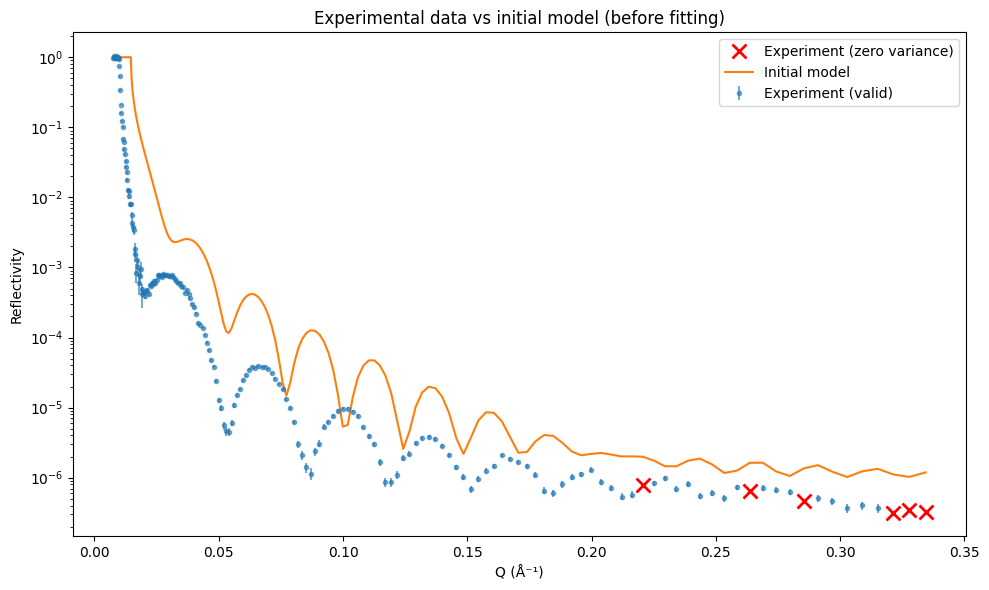

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(q_raw[valid], r_raw[valid], yerr=err_raw[valid],
            fmt='o', ms=3, color='C0', alpha=0.6, label='Experiment (valid)')
ax.plot(q_raw[zero_mask], r_raw[zero_mask],
        'rx', ms=10, mew=2, label='Experiment (zero variance)')
ax.plot(q_raw, r_init, '-', color='C1', lw=1.5, label='Initial model')

ax.set_yscale('log')
ax.set_xlabel('Q (Å⁻¹)')
ax.set_ylabel('Reflectivity')
ax.set_title('Experimental data vs initial model (before fitting)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Set Fitting Parameters and Constraints

In [11]:
sio2_layer.thickness.fixed = False
sio2_layer.thickness.bounds = (15, 50)

film_layer.thickness.fixed = False
film_layer.thickness.bounds = (200, 300)

film.sld.fixed = False
film.sld.bounds = (0.1, 3)

model.background.fixed = False
model.background.bounds = (1e-7, 1e-5)

model.scale.fixed = False
model.scale.bounds = (0.5, 1.5)

print('Free parameters:')
for p in model.get_fit_parameters():
    print(f'  {p.name:20s} = {float(p.value):.4g}  bounds={p.bounds}')

Free parameters:
  thickness            = 30  bounds=(15, 50)
  sld                  = 2  bounds=(0.1, 3)
  thickness            = 250  bounds=(200, 300)
  scale                = 1  bounds=(0.5, 1.5)
  background           = 1e-06  bounds=(1e-07, 1e-05)


## 10. Zero-Variance Handling — Three Objective Modes

We now fit the same data with each objective mode and compare the results.

### How each mode handles zero-variance points

- **`legacy_mask`** — zero-variance points are dropped before fitting. The fitter sees fewer
  data points, and those Q-values have no influence on the result.
- **`hybrid`** (default) — valid points use standard weighted least-squares ($w = 1/\sigma$).
  Zero-variance points get the **Mighell (1999)** substitution:
  $y_\text{eff} = y + \min(y, 1)$, $\sigma = \sqrt{\max(y + 1,\, \varepsilon)}$.
  This keeps all data in the fit while giving zero-variance points reasonable weight.
- **`mighell`** — applies the Mighell transform to *every* point, not just zero-variance ones.
  This changes the chi-square landscape for the entire dataset.

In [12]:
def build_fresh_model():
    """Build a fresh model+interface so each fit starts from the same initial state."""
    _si = Material(2.07, 0, 'Si')
    _sio2 = Material(3.47, 0, 'SiO2')
    _film = Material(2.0, 0, 'Film')
    _d2o = Material(6.36, 0, 'D2O')

    _si_layer = Layer(_si, 0, 0, 'Si layer')
    _sio2_layer = Layer(_sio2, 30, 3, 'SiO2 layer')
    _film_layer = Layer(_film, 250, 3, 'Film layer')
    _superphase = Layer(_d2o, 0, 3, 'D2O superphase')

    _sample = Sample(
        Multilayer(_si_layer),
        Multilayer(_sio2_layer),
        Multilayer(_film_layer),
        Multilayer(_superphase),
        name='Film Structure',
    )
    _resolution = PercentageFwhm(0.02)
    _model = Model(_sample, 1, 1e-6, _resolution, 'Film Model')

    _sio2_layer.thickness.fixed = False
    _sio2_layer.thickness.bounds = (15, 50)
    _film_layer.thickness.fixed = False
    _film_layer.thickness.bounds = (200, 300)
    _film.sld.fixed = False
    _film.sld.bounds = (0.1, 3)
    _model.background.fixed = False
    _model.background.bounds = (1e-7, 1e-5)
    _model.scale.fixed = False
    _model.scale.bounds = (0.5, 1.5)

    _model.interface = CalculatorFactory()
    return _model

### 11. Fit with `legacy_mask`

Zero-variance points are simply dropped.

In [13]:
model_mask = build_fresh_model()
fitter_mask = MultiFitter(model_mask, objective='legacy_mask')

with warnings.catch_warnings(record=True) as w_mask:
    warnings.simplefilter('always')
    result_mask = fitter_mask.fit(data)

for w in w_mask:
    print(f'[WARNING] {w.message}')
print(f'Success      : {result_mask["success"]}')
print(f'Reduced chi² : {result_mask["reduced_chi"]:.4f}')

r_fit_mask = model_mask.interface.fit_func(q_raw, model_mask.unique_name)

[WARNING] Masked 6 data point(s) in reflectivity ref_zero_var due to zero variance during fitting.
Success      : True
Reduced chi² : 286.8691


### 12. Fit with `hybrid` (new default)

All points kept; Mighell substitution applied only to zero-variance entries.

In [14]:
model_hybrid = build_fresh_model()
fitter_hybrid = MultiFitter(model_hybrid, objective='hybrid')

with warnings.catch_warnings(record=True) as w_hybrid:
    warnings.simplefilter('always')
    result_hybrid = fitter_hybrid.fit(data)

for w in w_hybrid:
    print(f'[WARNING] {w.message}')
print(f'Success      : {result_hybrid["success"]}')
print(f'Reduced chi² : {result_hybrid["reduced_chi"]:.4f}')

r_fit_hybrid = model_hybrid.interface.fit_func(q_raw, model_hybrid.unique_name)

[WARNING] Applied Mighell substitution to 6 zero-variance point(s) in reflectivity ref_zero_var during fitting.
Success      : True
Reduced chi² : 277.6647


### 13. Fit with `mighell`

Mighell transform applied to *all* points — the chi² landscape changes entirely.

In [15]:
model_mighell = build_fresh_model()
fitter_mighell = MultiFitter(model_mighell, objective='mighell')

with warnings.catch_warnings(record=True) as w_mighell:
    warnings.simplefilter('always')
    result_mighell = fitter_mighell.fit(data)

for w in w_mighell:
    print(f'[WARNING] {w.message}')
print(f'Success      : {result_mighell["success"]}')
print(f'Reduced chi² : {result_mighell["reduced_chi"]:.6f}')

r_fit_mighell = model_mighell.interface.fit_func(q_raw, model_mighell.unique_name)

[WARNING] Applied Mighell substitution to 192 zero-variance point(s) in reflectivity ref_zero_var during fitting.
Success      : True
Reduced chi² : 0.095375


## 14. Compare Fit Results

### Parameter comparison table

In [21]:
models = {
    'legacy_mask': model_mask,
    'hybrid': model_hybrid,
    'mighell': model_mighell,
}
results = {
    'legacy_mask': result_mask,
    'hybrid': result_hybrid,
    'mighell': result_mighell,
}

# Build descriptive labels to disambiguate duplicates (e.g. two "thickness" params)
ref_params = model_mask.get_fit_parameters()
seen = {}
labels = []
for p in ref_params:
    n = p.name
    seen[n] = seen.get(n, 0) + 1
    labels.append(f'{n} ({seen[n]})')
# Simplify if name appears only once
name_counts = {}
for p in ref_params:
    name_counts[p.name] = name_counts.get(p.name, 0) + 1
labels_clean = []
seen2 = {}
for p in ref_params:
    n = p.name
    seen2[n] = seen2.get(n, 0) + 1
    if name_counts[n] > 1:
        labels_clean.append(f'{n}_{seen2[n]}')
    else:
        labels_clean.append(n)

obj_keys = ['legacy_mask', 'hybrid', 'mighell']

header = f'{"Parameter":<20s} {"legacy_mask":>14s} {"hybrid":>14s} {"mighell":>14s}'
print(header)
print('-' * len(header))

for i, label in enumerate(labels_clean):
    vals = []
    for obj in obj_keys:
        params = models[obj].get_fit_parameters()
        vals.append(float(params[i].value))
    print(f'{label:<20s} {vals[0]:>14.4g} {vals[1]:>14.4g} {vals[2]:>14.4g}')

print('-' * len(header))
print(f'{"reduced chi²":<20s} {result_mask["reduced_chi"]:>14.4f} {result_hybrid["reduced_chi"]:>14.4f} {result_mighell["reduced_chi"]:>14.6f}')
print(f'{"success":<20s} {str(result_mask["success"]):>14s} {str(result_hybrid["success"]):>14s} {str(result_mighell["success"]):>14s}')

Parameter               legacy_mask         hybrid        mighell
-----------------------------------------------------------------
thickness_1                0.002002       0.001911          593.4
sld                          -11.06         -11.06          5.516
thickness_2                   211.4          211.4          364.7
scale                      0.007455       0.007455         0.7049
background                5.389e-07      5.389e-07      7.115e-08
-----------------------------------------------------------------
reduced chi²               286.8691       277.6647       0.095375
success                        True           True           True


### Fitted reflectivity curves — all three objectives

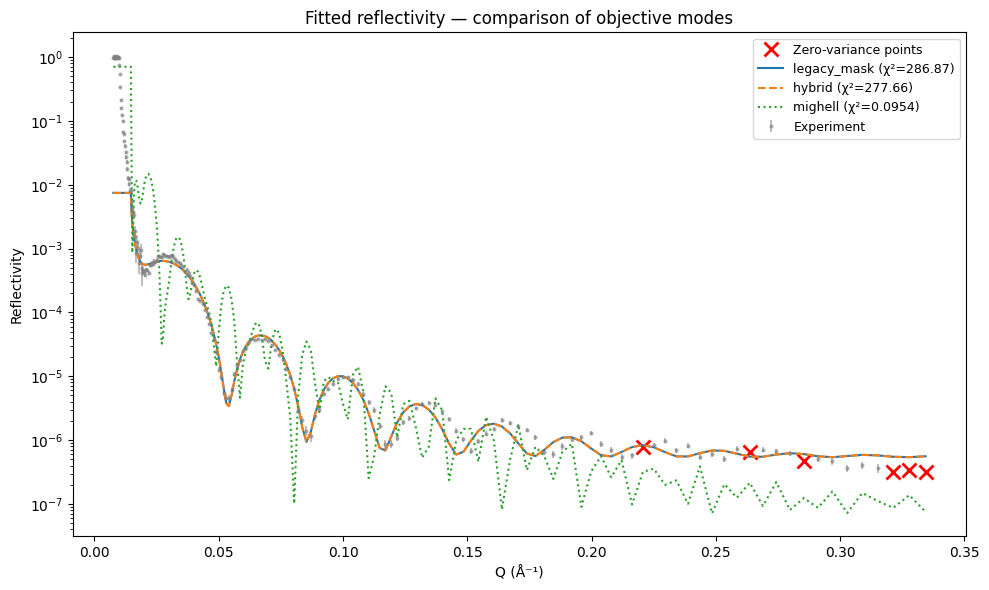

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Experimental data
ax.errorbar(q_raw[valid], r_raw[valid], yerr=err_raw[valid],
            fmt='o', ms=2, color='grey', alpha=0.5, label='Experiment')
ax.plot(q_raw[zero_mask], r_raw[zero_mask],
        'rx', ms=10, mew=2, label='Zero-variance points')

# Fitted curves
ax.plot(q_raw, r_fit_mask, '-', lw=1.5, label=f'legacy_mask (χ²={result_mask["reduced_chi"]:.2f})')
ax.plot(q_raw, r_fit_hybrid, '--', lw=1.5, label=f'hybrid (χ²={result_hybrid["reduced_chi"]:.2f})')
ax.plot(q_raw, r_fit_mighell, ':', lw=1.5, label=f'mighell (χ²={result_mighell["reduced_chi"]:.4f})')

ax.set_yscale('log')
ax.set_xlabel('Q (Å⁻¹)')
ax.set_ylabel('Reflectivity')
ax.set_title('Fitted reflectivity — comparison of objective modes')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 15. Examine Residuals

We compute normalised residuals $(R_\text{exp} - R_\text{model}) / \sigma$ for each objective.
Zero-variance points are shown separately — for `legacy_mask` they were excluded from
the fit, while `hybrid` and `mighell` included them with transformed weights.

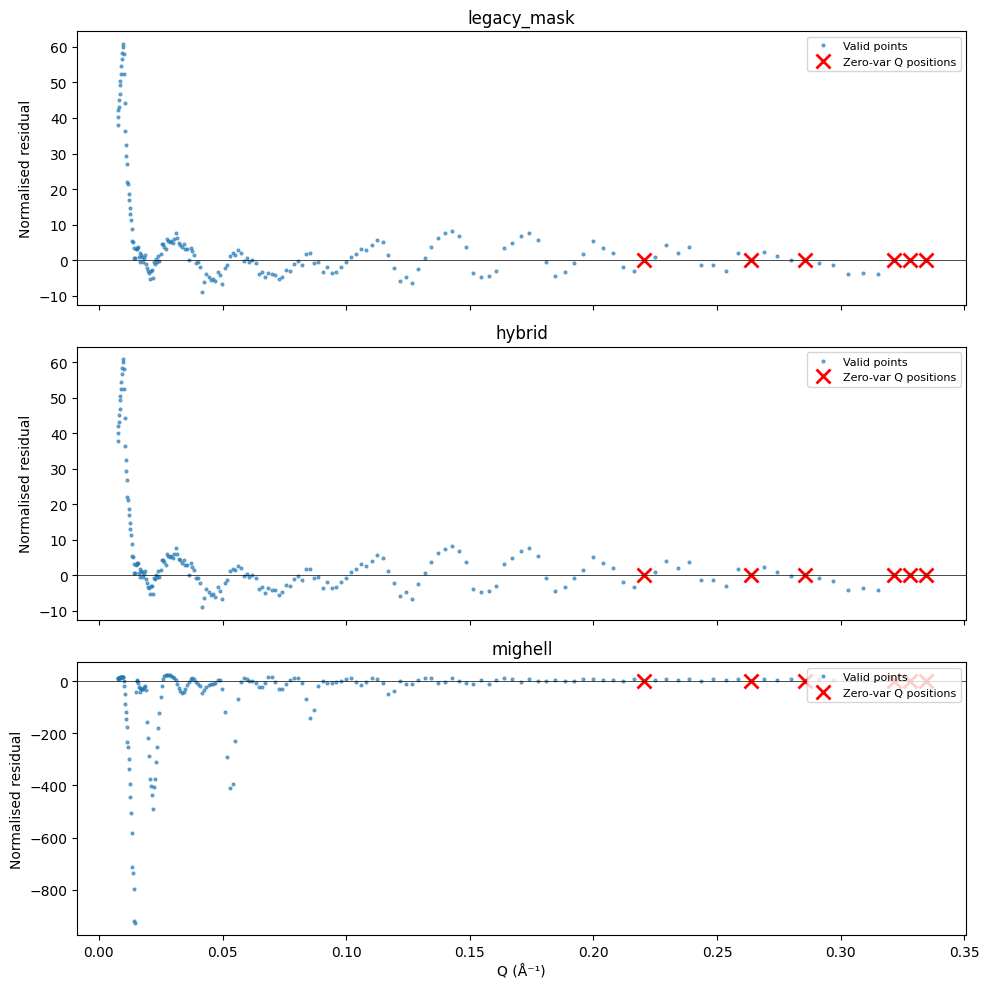

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

fits = {
    'legacy_mask': r_fit_mask,
    'hybrid': r_fit_hybrid,
    'mighell': r_fit_mighell,
}

for ax, (obj_name, r_fit) in zip(axes, fits.items()):
    # Normalised residuals for valid points
    residuals_valid = (r_raw[valid] - r_fit[valid]) / err_raw[valid]
    ax.plot(q_raw[valid], residuals_valid, 'o', ms=2, alpha=0.6, color='C0', label='Valid points')

    # Un-normalised residuals at zero-variance points (no sigma to normalise by)
    residuals_zero = r_raw[zero_mask] - r_fit[zero_mask]
    ax.plot(q_raw[zero_mask], np.zeros_like(residuals_zero), 'rx', ms=10, mew=2,
            label='Zero-var Q positions')

    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Normalised residual')
    ax.set_title(f'{obj_name}')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Q (Å⁻¹)')
plt.tight_layout()
plt.show()

## Summary

| Objective | Zero-var handling | Chi² interpretation |
|---|---|---|
| `legacy_mask` | Dropped from fit | Classical reduced χ² |
| `hybrid` | Mighell substitution for zero-var only | Approximately classical when zero-var fraction is small |
| `mighell` | Mighell transform for **all** points | **Not** a classical χ² — values are not directly comparable |

The `hybrid` mode (new default) is recommended: it keeps all data points in the fit while
producing chi² values that remain approximately classical. The `mighell` mode is useful when
the entire dataset has low counts and Poisson-like statistics are desired.